In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/xband_info_g.csv')
info

,source,l,b,theta,phi,nfw,nfw_sq,iso,iso_sq,burkert,burkert_sq,moore,moore_sq
0,HIP31319,186.351085,8.695369,96.277791,169.246613,9.989327e+07,4.985144e+14,2.521213e+08,1.142265e+15,8.550127e+07,4.070035e+14,2.178480e+07,2.878614e+13
1,HIP32010,190.341431,8.572469,100.224648,166.597332,1.002477e+08,5.013753e+14,2.526114e+08,1.146475e+15,8.582101e+07,4.093366e+14,2.186996e+07,2.896046e+13
2,HIP109474,110.001367,11.409925,22.910600,109.589732,1.317070e+08,7.926500e+14,2.910501e+08,1.506253e+15,1.140915e+08,6.436282e+14,2.958756e+07,4.714941e+13
3,HIP108917,106.158302,7.365894,17.717209,106.021354,1.357860e+08,8.360996e+14,2.953828e+08,1.550574e+15,1.177252e+08,6.779158e+14,3.061020e+07,4.993177e+13
4,HIP108110,106.680210,9.628666,19.191186,106.438508,1.352906e+08,8.307496e+14,2.948637e+08,1.545222e+15,1.172845e+08,6.737044e+14,3.048574e+07,4.958828e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1919,HIP15887,149.806492,-10.597138,60.373468,148.167127,1.050097e+08,5.406830e+14,2.590606e+08,1.202746e+15,9.011593e+07,4.413427e+14,2.301803e+07,3.136458e+13
1920,HIP17060,153.540710,-10.981984,64.061744,151.504736,1.038346e+08,5.308310e+14,2.574921e+08,1.188912e+15,8.905625e+07,4.333300e+14,2.273404e+07,3.076043e+13
1921,HIP17042,153.751239,-11.330181,64.300575,151.570461,1.038130e+08,5.306502e+14,2.574630e+08,1.188657e+15,8.903670e+07,4.331829e+14,2.272880e+07,3.074936e+13
1922,HIP18912,159.467523,-10.845547,69.850349,156.889010,1.022395e+08,5.176167e+14,2.553390e+08,1.170077e+15,8.761752e+07,4.225729e+14,2.234923e+07,2.995176e+13


# Doppler asymmetry

In [8]:
from astropy.coordinates import SkyCoord
cutoff = 65
forward = info[info['theta'] < cutoff]
backward = info[info['theta'] > cutoff]
ls_forward, bs_forward = forward['l'], forward['b']
ls_backward, bs_backward = backward['l'], backward['b']
gal_forward = SkyCoord(ls_forward, bs_forward, unit='deg', frame='galactic')
gal_backward = SkyCoord(ls_backward, bs_backward, unit='deg', frame='galactic')

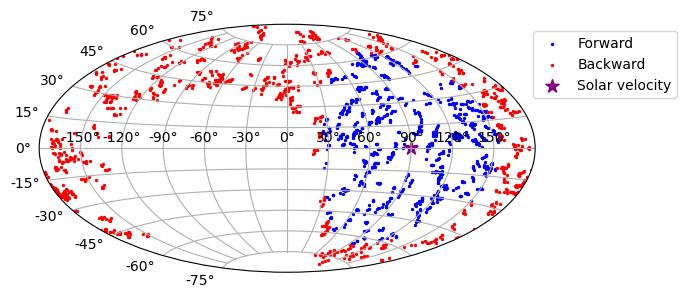

In [24]:
plt.subplot(111, projection='aitoff')
plt.grid(True)
plt.scatter(gal_forward.l.wrap_at('180d').radian, gal_forward.b.radian, s=2, c='blue', label='Forward')
plt.scatter(gal_backward.l.wrap_at('180d').radian, gal_backward.b.radian, s=2, c='red', label='Backward')
plt.scatter(np.pi/2, 0, marker='*', color='purple', s=100, label='Solar velocity')
plt.legend(bbox_to_anchor=(1.3, 1), loc='upper right')

In [25]:
normalized_injected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/normalized_injected_test/'

In [34]:
forward_spectra = np.array([np.load(normalized_injected_dir + name + '.npy')[1] for name in forward['source']])
backward_spectra = np.array([np.load(normalized_injected_dir + name + '.npy')[1] for name in backward['source']])
forward_mean = np.mean(forward_spectra, axis=0)
backward_mean = np.mean(backward_spectra, axis=0)
asymmetry = (forward_mean - backward_mean) / (forward_mean + backward_mean)

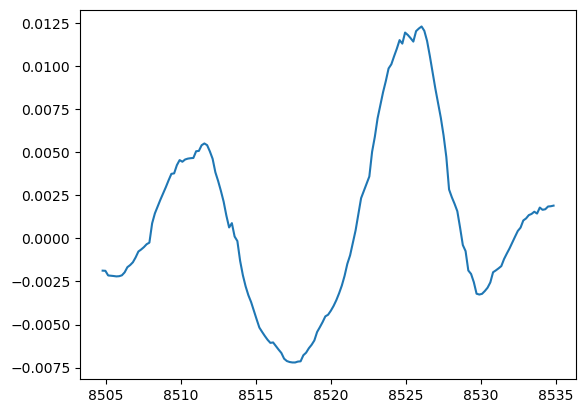

In [35]:
xs = np.load(normalized_injected_dir + os.listdir(normalized_injected_dir)[0])[0]
plt.plot(xs, asymmetry)

# Intensity asymmetry

In [38]:
lower_cutoff = 70
upper_cutoff = 115
inward = info[info['phi'] < lower_cutoff]
outward = info[info['phi'] > upper_cutoff]
ls_inward, bs_inward = inward['l'], inward['b']
ls_outward, bs_outward = outward['l'], outward['b']
gal_inward = SkyCoord(ls_inward, bs_inward, unit='deg', frame='galactic')
gal_outward = SkyCoord(ls_outward, bs_outward, unit='deg', frame='galactic')

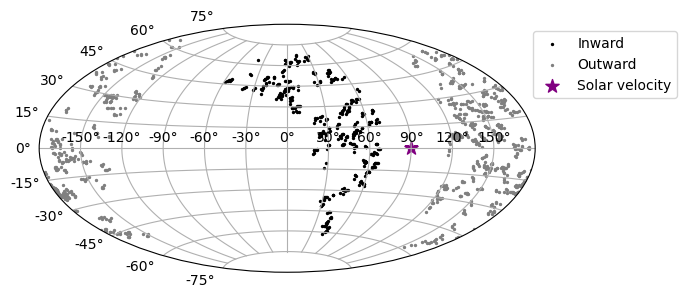

In [39]:
plt.subplot(111, projection='aitoff')
plt.grid(True)
plt.scatter(gal_inward.l.wrap_at('180d').radian, gal_inward.b.radian, s=2, c='black', label='Inward')
plt.scatter(gal_outward.l.wrap_at('180d').radian, gal_outward.b.radian, s=2, c='gray', label='Outward')
plt.scatter(np.pi/2, 0, marker='*', color='purple', s=100, label='Solar velocity')
plt.legend(bbox_to_anchor=(1.3, 1), loc='upper right')

In [40]:
inward_spectra = np.array([np.load(normalized_injected_dir + name + '.npy')[1] for name in inward['source']])
outward_spectra = np.array([np.load(normalized_injected_dir + name + '.npy')[1] for name in outward['source']])
inward_mean = np.mean(inward_spectra, axis=0)
outward_mean = np.mean(outward_spectra, axis=0)
asymmetry = (inward_mean - outward_mean) / (inward_mean + outward_mean)

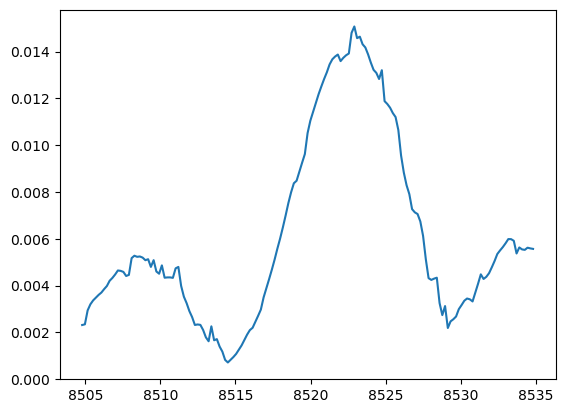

In [41]:
xs = np.load(normalized_injected_dir + os.listdir(normalized_injected_dir)[0])[0]
plt.plot(xs, asymmetry)

# Asymmetry builder

In [2]:
def build_asymmetry(data_dir, info, angle, lower, upper, spectra=None):
    if not spectra:
        spectra = os.listdir(data_dir)
    inner = info[info[angle] < lower]
    outer = info[info[angle] > upper]
    inner_spectra = np.array([np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in inner['source'].tolist()])
    outer_spectra = np.array([np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in outer['source'].tolist()])
    print(inner_spectra)
    inner_mean = np.mean(inner_spectra, axis=0)
    outer_mean = np.mean(outer_spectra, axis=0)
    asymmetry = (inner_mean - outer_mean) / (inner_mean + outer_mean)
    xs = np.load(os.path.join(data_dir, spectra[0]))[0]
    return xs, asymmetry

In [55]:
normalized_injected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/normalized_injected_test/'
normalized_uninjected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_062525/normalized_uninjected_test/'
doppler_inj_xs, doppler_inj_ys = build_asymmetry(normalized_injected_dir, info, 'theta', 65, 65)
doppler_uninj_xs, doppler_uninj_ys = build_asymmetry(normalized_uninjected_dir, info, 'theta', 65, 65)
intensity_inj_xs, intensity_inj_ys = build_asymmetry(normalized_injected_dir, info, 'phi', 70, 115)
intensity_uninj_xs, intensity_uninj_ys = build_asymmetry(normalized_uninjected_dir, info, 'phi', 70, 115)

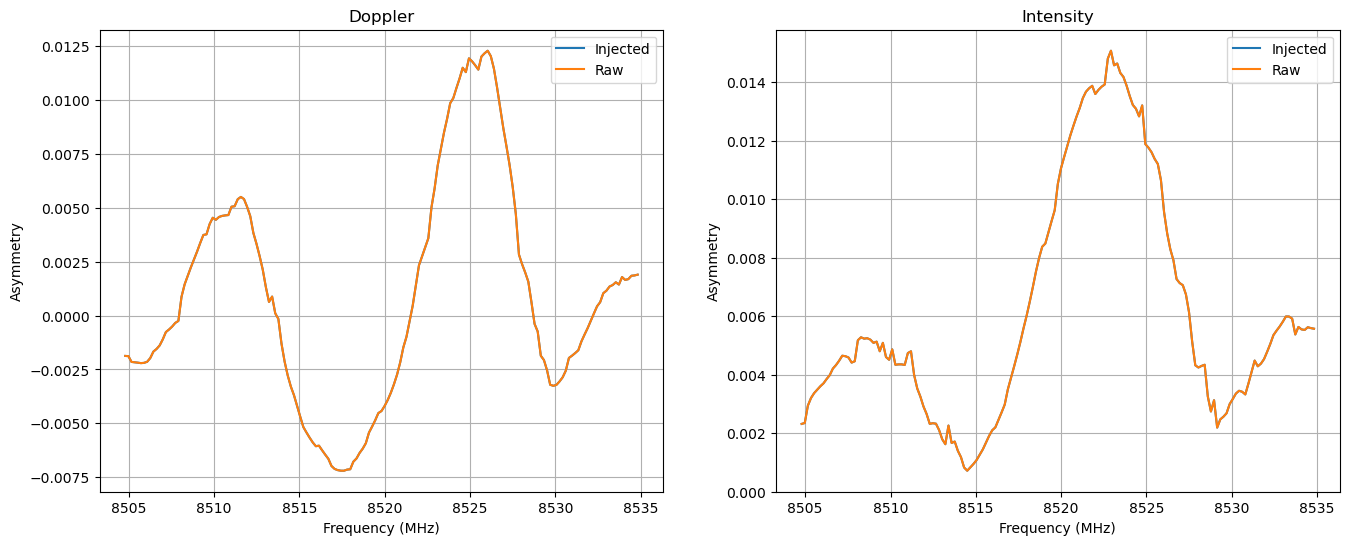

In [56]:
fig, axs = plt.subplots(1, 2, figsize=(16,6))
axs[0].plot(doppler_inj_xs, doppler_inj_ys, label='Injected')
axs[0].plot(doppler_uninj_xs, doppler_uninj_ys, label='Raw')
axs[0].set_title('Doppler')
axs[1].plot(intensity_inj_xs, intensity_inj_ys, label='Injected')
axs[1].plot(intensity_uninj_xs, intensity_uninj_ys, label='Raw')
axs[1].set_title('Intensity')
for ax in axs:
    ax.grid()
    ax.set_xlabel('Frequency (MHz)')
    ax.set_ylabel('Asymmetry')
    ax.legend()

# New target list for Bayesian optimization

In [4]:
info = pd.read_csv('/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/spliced/all_xband_info.csv')
info

,source,epoch,time,ra,dec,l,b,theta,phi,nfw,nfw_sq,iso,iso_sq,burkert,burkert_sq,moore,moore_sq
0,HIP62637,AGBT23B_999_14,60291_31980,192.5380,19.8676,300.540925,82.733377,96.254146,86.314790,1.660433e+08,1.202716e+15,3.237142e+08,1.860099e+15,1.442647e+08,9.590752e+14,3.834180e+07,7.402785e+13
1,HIP38468,AGBT20B_999_54,59214_38477,118.1838,12.0399,208.821296,18.974616,117.121857,145.947125,1.058735e+08,5.479899e+14,2.602043e+08,1.212893e+15,9.089486e+07,4.472811e+14,2.322709e+07,3.181333e+13
2,HIP116538,AGBT20B_999_49,59203_03185,354.3079,57.9490,113.193170,-3.512770,23.443145,113.147054,1.279805e+08,7.541369e+14,2.869724e+08,1.465254e+15,1.107629e+08,6.130784e+14,2.865754e+07,4.469731e+13
3,HIP96264,AGBT20B_999_49,59203_36476,293.5826,71.6109,103.349354,22.362166,25.866928,102.328982,1.403981e+08,8.868837e+14,3.001235e+08,1.599971e+15,1.218205e+08,7.177445e+14,3.177227e+07,5.320469e+13
4,HIP53862,AGBT20A_999_44,59023_07533,165.2817,-5.7016,259.734245,47.703048,131.467876,96.888255,1.479999e+08,9.745009e+14,3.075883e+08,1.679683e+15,1.285353e+08,7.858121e+14,3.370077e+07,5.890246e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,HIP6529,AGBT20B_996_01,59225_75932,20.9600,25.9246,131.988102,-36.376712,53.241482,122.589484,1.195448e+08,6.710386e+14,2.772991e+08,1.370729e+15,1.032019e+08,5.466822e+14,2.656755e+07,3.945346e+13
4995,HIP5701,AGBT20B_996_01,59225_76780,18.3398,25.4659,129.141570,-37.141396,51.810902,120.211314,1.214849e+08,6.896553e+14,2.795800e+08,1.392673e+15,1.049437e+08,5.616120e+14,2.704631e+07,4.062254e+13
4996,HIP5777,AGBT20B_996_01,59225_78072,18.5185,25.8356,129.291960,-36.756451,51.679375,120.488749,1.212525e+08,6.874098e+14,2.793086e+08,1.390051e+15,1.047351e+08,5.598128e+14,2.698890e+07,4.048135e+13
4997,HIP5965,AGBT20B_996_01,59225_77421,19.1727,24.5039,130.227874,-38.009838,53.018922,120.587397,1.211702e+08,6.866161e+14,2.792124e+08,1.389122e+15,1.046613e+08,5.591768e+14,2.696859e+07,4.043146e+13


In [7]:
inward_sources = info[info['phi'] < 70]['source'].tolist()
outward_sources = info[info['phi'] > 115]['source'].tolist()
len(inward_sources), len(outward_sources)

(394, 2408)

In [6]:
import random
inward_choice = random.sample(inward_sources, 200)
outward_choice = random.sample(outward_sources, 200)
print(inward_choice, outward_choice)

['HIP100015', 'HIP109038', 'HIP81461', 'HIP67377', 'HIP61867', 'HIP76538', 'HIP77669', 'HIP102565', 'HIP65116', 'HIP77137', 'HIP98924', 'HIP99476', 'HIP72567', 'HIP99317', 'HIP63959', 'HIP99473', 'HIP98241', 'HIP106243', 'HIP63137', 'HIP99995', 'HIP80885', 'HIP82389', 'HIP90041', 'HIP76267', 'HIP81410', 'HIP69681', 'HIP78464', 'HIP71807', 'HIP80392', 'HIP77367', 'HIP84190', 'HIP84521', 'HIP98964', 'HIP64573', 'HIP66423', 'HIP79692', 'HIP102490', 'HIP91856', 'HIP99117', 'HIP97051', 'HIP83627', 'HIP94747', 'HIP98819', 'HIP72550', 'HIP72603', 'HIP96174', 'HIP86277', 'HIP81704', 'HIP96842', 'HIP78075', 'HIP99210', 'HIP90175', 'HIP96166', 'HIP88389', 'HIP77485', 'HIP96205', 'HIP72382', 'HIP95893', 'HIP82476', 'HIP75850', 'HIP98617', 'HIP81421', 'HIP77165', 'HIP92374', 'HIP95293', 'HIP102671', 'HIP95677', 'HIP95949', 'HIP109822', 'HIP75057', 'HIP81365', 'HIP81690', 'HIP100064', 'HIP80460', 'HIP103545', 'HIP77060', 'HIP88474', 'HIP83058', 'HIP95847', 'HIP105759', 'HIP83691', 'HIP76646', 'HIP9

In [8]:
choice = inward_choice + outward_choice

In [11]:
normalized_uninjected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/spliced/2/normalized_uninjected_w'
normalized_injected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/spliced/2/normalized_injected_w'
uninj_old = build_asymmetry(normalized_uninjected_dir, info, 'phi', 70, 115)
inj_old = build_asymmetry(normalized_injected_dir, info, 'phi', 70, 115)

[[0.99994163 0.99994197 0.99993005 ... 0.99737067 0.99815371 0.99887525]
 [0.99993169 0.99993205 0.9999189  ... 0.99742419 0.99819535 0.99890048]
 [1.0000283  1.00002451 1.00000887 ... 1.00421989 1.0058554  1.0076659 ]
 ...
 [1.00002216 1.00001849 1.00000497 ... 1.00404258 1.00566624 1.0074692 ]
 [0.99999217 0.99999287 0.99999313 ... 0.99732456 0.99805833 0.99875421]
 [1.00002027 1.00001641 0.99999929 ... 1.00401755 1.00564846 1.00745759]]
[[1.00057061 1.00034044 0.99924388 ... 0.99735721 0.99814223 0.9988662 ]
 [1.00049316 1.0002606  0.99914624 ... 0.99735574 0.99814189 0.9988666 ]
 [0.99313873 0.99321539 0.99237134 ... 0.99742419 0.99819535 0.99890048]
 ...
 [0.99959787 0.99931612 0.99788672 ... 0.99732236 0.99805693 0.99875281]
 [0.99963748 0.99935395 0.99792108 ... 0.99732456 0.99805833 0.99875421]
 [0.9939522  0.99381037 0.99206632 ... 1.00401755 1.00564846 1.00745759]]


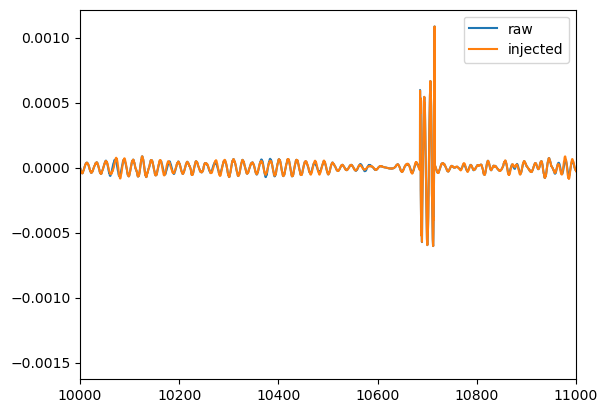

In [13]:
plt.plot(*uninj_old, label='raw')
plt.plot(*inj_old, label='injected')
plt.xlim(10000,11000)
#plt.ylim(-0.0001, 0.0001)
plt.legend()

In [52]:
files = [name + '.npy' for name in choice if name + '.npy' in os.listdir(normalized_uninjected_dir)]
files

['HIP79465.npy',
 'HIP66637.npy',
 'HIP85810.npy',
 'HIP98825.npy',
 'HIP61951.npy',
 'HIP102671.npy',
 'HIP77490.npy',
 'HIP94747.npy',
 'HIP72382.npy',
 'HIP90035.npy',
 'HIP77139.npy',
 'HIP79492.npy',
 'HIP105965.npy',
 'HIP80460.npy',
 'HIP88389.npy',
 'HIP102029.npy',
 'HIP85047.npy',
 'HIP81217.npy',
 'HIP99316.npy',
 'HIP72363.npy',
 'HIP77455.npy',
 'HIP97056.npy',
 'HIP91926.npy',
 'HIP78080.npy',
 'HIP82341.npy',
 'HIP78069.npy',
 'HIP96388.npy',
 'HIP79695.npy',
 'HIP95677.npy',
 'HIP75312.npy',
 'HIP102602.npy',
 'HIP75875.npy',
 'HIP80392.npy',
 'HIP71807.npy',
 'HIP99938.npy',
 'HIP97675.npy',
 'HIP77572.npy',
 'HIP90148.npy',
 'HIP62954.npy',
 'HIP69562.npy',
 'HIP78497.npy',
 'HIP64672.npy',
 'HIP75913.npy',
 'HIP69681.npy',
 'HIP96229.npy',
 'HIP89944.npy',
 'HIP89825.npy',
 'HIP76670.npy',
 'HIP103256.npy',
 'HIP86277.npy',
 'HIP76647.npy',
 'HIP97208.npy',
 'HIP103386.npy',
 'HIP81461.npy',
 'HIP102611.npy',
 'HIP88474.npy',
 'HIP69455.npy',
 'HIP84012.npy',
 'HIP82

[[0.99988835 0.99989933 0.99991899 ... 1.00014762 1.00160015 1.00293046]
 [0.99967981 0.99967295 0.99959011 ... 1.00238443 1.00218806 1.00183462]
 [0.99969658 0.99968835 0.99960322 ... 1.0025253  1.00242434 1.00215888]
 ...
 [0.99987704 0.99988907 0.99990868 ... 1.00046206 1.0019063  1.00325198]
 [0.99972732 0.99972192 0.99965491 ... 1.00260025 1.00251359 1.00226508]
 [0.99968784 0.99967919 0.99959241 ... 1.0025495  1.00244373 1.00217247]]
[[0.99705731 0.99701755 0.99676732 ... 1.00014762 1.00160015 1.00293046]
 [0.99714206 0.99779288 0.99921064 ... 1.00238443 1.00218806 1.00183462]
 [0.99389695 0.99301561 0.98895627 ... 1.0025253  1.00242434 1.00215888]
 ...
 [0.99773855 0.99798154 0.99850641 ... 1.00046206 1.0019063  1.00325198]
 [0.98955367 0.99023157 0.99116549 ... 1.00260025 1.00251359 1.00226508]
 [1.00225468 1.00107638 0.9960396  ... 1.0025495  1.00244373 1.00217247]]
why? (array([7703.7062645 , 7703.88936996, 7704.07247543, ..., 8986.17696762,
       8986.36007309, 8986.5431785

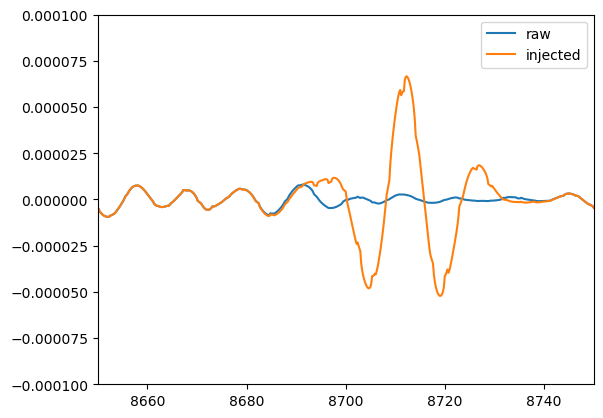

In [54]:
uninj_new = build_asymmetry(normalized_uninjected_dir, info, 'phi', 70, 115, spectra=files)
inj_new = build_asymmetry(normalized_injected_dir, info, 'phi', 70, 115, spectra=files)
print('why?', uninj_new)
plt.plot(*uninj_new, label='raw')
plt.plot(*inj_new, label='injected')
plt.xlim(8650,8750)
plt.ylim(-0.0001, 0.0001)
plt.legend()

In [68]:
# Writing the 200 choices
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/'
import os

with open(os.path.join(data_dir, 'snr_targets_400.txt'), 'w') as file:
    for item in choice:
        file.write(f'{item}\n') # Writes each item followed by a newline

# WHYYYYYYYY?!?!?!?

In [3]:
targets = []
ddir ='/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/'
with open(os.path.join(ddir, 'snr_targets_200.txt'), 'r') as file: #random_names.txt
    for line in file:
        targets.append(line.strip())

[[0.96623391 0.92779852 0.92698906 ... 0.99165793 0.99142449 0.9899841 ]
 [0.97885677 0.97746258 0.97842524 ... 0.9952453  0.99550635 0.9946429 ]
 [0.96901173 0.97074098 0.97027114 ... 0.98814614 0.98697228 0.98485405]
 ...
 [1.00064729 1.00062685 1.00061055 ... 1.03370026 1.03150563 1.03101214]
 [0.96520895 0.97021227 0.96901758 ... 0.98662892 0.98483987 0.98239759]
 [1.00462938 1.00483256 1.00054378 ... 1.03569593 1.03352073 1.03284931]]
[[0.96987773 0.97592597 0.97514445 ... 0.99474897 0.99482103 0.99379941]
 [0.99108444 0.98289291 0.98251912 ... 0.99778355 0.99710857 0.99638966]
 [0.99164602 0.98362104 0.98365274 ... 0.9977399  0.99696442 0.99621595]
 ...
 [0.99109316 0.98146797 0.98064241 ... 0.99797993 0.99775089 0.99713774]
 [1.00416488 1.00060119 1.00057297 ... 1.03254099 1.03092274 1.03058606]
 [1.00064729 1.00062686 1.00061055 ... 1.03369981 1.03150626 1.03101229]]


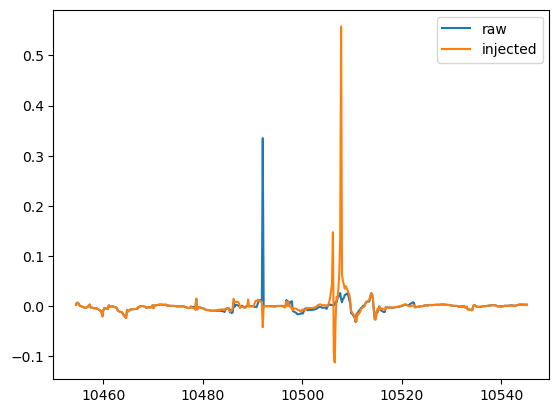

In [11]:
normalized_uninjected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/snr_bayes_new_27/2/normalized_uninjected'
normalized_injected_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/snr_bayes_new_27/2/normalized_injected'
uninj_weird = build_asymmetry(normalized_uninjected_dir, info, 'phi', 70, 115)
inj_weird = build_asymmetry(normalized_injected_dir, info, 'phi', 70, 115)
plt.plot(*uninj_weird, label='raw')
plt.plot(*inj_weird, label='injected')
# plt.xlim(8650,8750)
# plt.ylim(-0.0001, 0.0001)
plt.legend()

# Picking new signal locations...

In [5]:
c = 299792
v_virial = 250 # km/s
v_earth  = 225 # km/s
dm_profile = 'nfw'

info_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_071025/spliced/all_xband_info.csv'
info = pd.read_csv(info_dir)

os.chdir('/home/bhanselman/scripts')
from normalization_methods import *

In [3]:
import random

Text(0.5, 1.0, 'Annihilation')

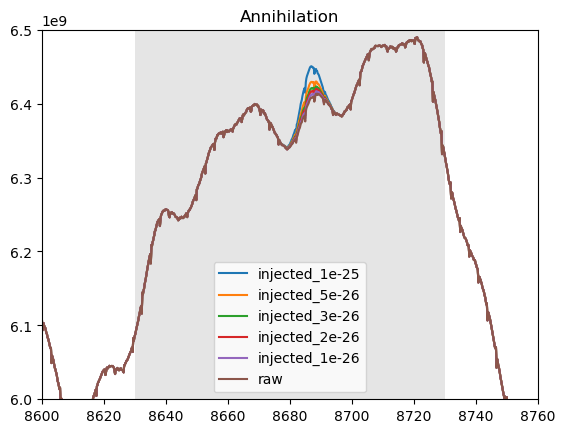

In [12]:
bank = 0
data_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed/{bank}'
name = os.listdir(data_dir)[1]
spectrum = np.load(os.path.join(data_dir, name))
freq = 8680

decay_sizes = [3e-29, 2e-29, 1e-29, 8e-30, 5e-30]
ann_sizes = [1e-25, 5e-26, 3e-26, 2e-26, 1e-26]

for signal_size in ann_sizes:
    inj_spectrum = inject(name, freq, info, data_dir=data_dir, signal_size=signal_size, is_decay=False)
    plt.plot(*inj_spectrum, label=f'injected_{signal_size}')

plt.plot(*spectrum, label='raw')    

xlim = (8600, 8760)
plt.axvspan(8630, 8730, color='gray', alpha=0.2, linewidth=0)
plt.xlim(*xlim)
# window = inj_spectrum[1][(spectrum[0] < xlim[1]) & (spectrum[0] > xlim[0])]
# plt.ylim(np.min(window), np.max(window))
plt.ylim(6e9, 6.5e9)
plt.legend()
plt.title('Annihilation')

In [6]:
bank = 2
data_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed/{bank}'
spectra = os.listdir(data_dir)
name = random.choice(spectra)

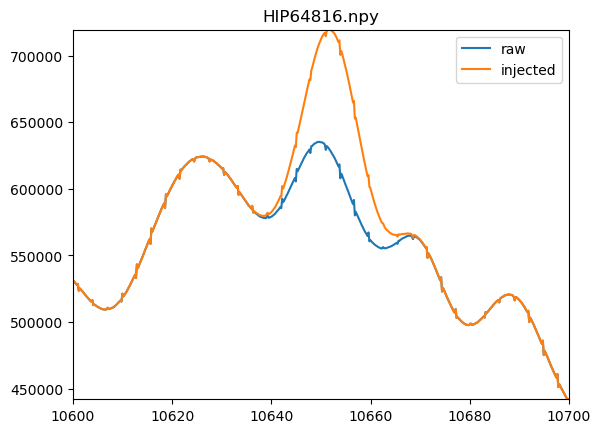

In [8]:
spectrum = np.load(os.path.join(data_dir, name))

inj_spectrum = spectrum
for freq in np.arange(10050, 11050, 200):
    signal_size = 5e-27 * (freq / 8500)**4
    inj_spectrum = inject(name, freq, data=inj_spectrum, signal_size=signal_size)
plt.plot(*spectrum, label='raw')
plt.plot(*inj_spectrum, label='injected')
xlim = (10600, 10700)
plt.xlim(*xlim)
window = inj_spectrum[1][(spectrum[0] < xlim[1]) & (spectrum[0] > xlim[0])]
plt.ylim(np.min(window), np.max(window))
plt.title(name)
plt.legend()

Text(0.5, 1.0, 'Decay')

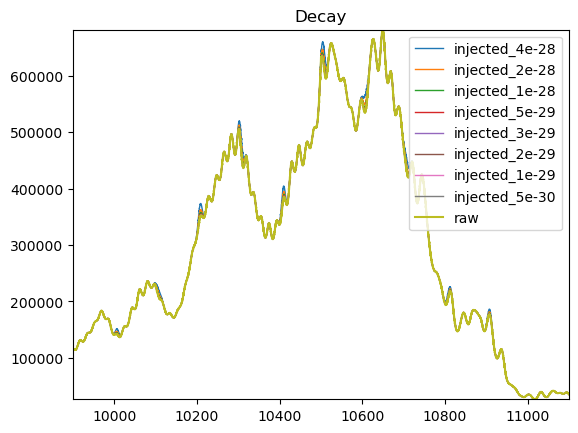

In [7]:
bank = 2
data_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed/{bank}'
name = os.listdir(data_dir)[1]
spectrum = np.load(os.path.join(data_dir, name))
start, stop, spacing = 10000, 11000, 100

decay_sizes = [4e-28, 2e-28, 1e-28, 5e-29, 3e-29, 2e-29, 1e-29, 5e-30]
ann_sizes = [1e-24, 5e-25, 2e-25, 1e-25, 5e-26, 3e-26, 2e-26, 1e-26]

for signal_size in decay_sizes:
    inj_spectrum = inject_spaced(name, start, stop, spacing, info, data_dir=data_dir, signal_size=signal_size, is_decay=True)
    plt.plot(*inj_spectrum, lw=1, label=f'injected_{signal_size}')

plt.plot(*spectrum, label='raw')    

xlim = (9900, 11100)
plt.xlim(*xlim)
window = inj_spectrum[1][(spectrum[0] < xlim[1]) & (spectrum[0] > xlim[0])]
plt.ylim(np.min(window), np.max(window))
plt.legend()
plt.title('Decay')

# Templates and cross-correlation

In [13]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/asymmetry_tests/8500_template/'

import numpy as np
import pandas as pd
import os
import multiprocessing as mp
import warnings
warnings.filterwarnings("ignore")
import random
from functools import partial
from scipy.optimize import curve_fit
import itertools
from tqdm import tqdm, trange
from functools import partial
import random
from bayes_opt import BayesianOptimization, acquisition
import math
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.stats import percentileofscore
from scipy.interpolate import interp1d

def build_asymmetry(data_dir, angle, lower, upper):
    spectra = os.listdir(data_dir)
    inner = info[info[angle] < lower]
    outer = info[info[angle] > upper]
    inner_spectra = np.array([np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in inner['source'].tolist()])
    outer_spectra = np.array([np.load(os.path.join(data_dir, file))[1] for file in spectra if file[:-4] in outer['source'].tolist()])
    inner_mean = np.mean(inner_spectra, axis=0)
    outer_mean = np.mean(outer_spectra, axis=0)
    asymmetry = (inner_mean - outer_mean) / (inner_mean + outer_mean)
    xs = np.load(os.path.join(data_dir, spectra[0]))[0]
    return xs, asymmetry


def correlate(freqs, spectrum, template, pad=False):
    def stretch_template(template, stretch_factor):
        #stretch_factor=1
        # stretch_factor: (0, inf) real number to horizontally scale the template by
        # assumption: center of the template is the center to stretch by, template has odd length
        assert template.shape[0] % 2 == 1, 'Template must have odd number of points'
        k = template.shape[0] // 2
        orig_x = np.arange(-k, k+1)
        interp_func = interp1d(orig_x, template, bounds_error=False, fill_value=0)
        new_k = ((2*k + 1)/stretch_factor - 1)/2 # 2k_1 + 1 = sf*(2k_0 + 1)
        new_x = np.linspace(-new_k, new_k, template.shape[0])

        return interp_func(new_x)

    def get_a(target, template):
        return np.dot(target, template) / (np.dot(template, template) + 1e-12)
    
    a_vals = np.zeros_like(spectrum)
    residuals = np.zeros_like(spectrum)
    lower = (len(template) - 1) // 2
    upper = (len(template) + 1) // 2
    orig_freq = freqs[len(spectrum) // 2]
    for i in range(len(spectrum)):
        central_freq = freqs[i]
        stretched = stretch_template(template, central_freq / orig_freq)
        
        if i < lower:
            x = lower - i
            stretched = stretched[x:]
            window = spectrum[:i+upper]
        elif i > (len(spectrum) - upper):
            x = len(spectrum) - upper - i
            stretched = stretched[:x]
            window = spectrum[i-lower:]
        else:
            window = spectrum[i-lower:i+upper]
        
        a = get_a(window, stretched) 
        a_vals[i] = a 
        residuals[i] = np.sqrt(np.mean((a*stretched-window)**2)) 
    if pad:
        a_vals = np.pad(a_vals, len(stretched//2))
        residuals = np.pad(residuals, len(stretched)//2, mode='constant', constant_values=1)

    return a_vals / (residuals + 1e-12)


def plot_dist(save_dirs):

    uninj_save_dir, inj_save_dir, temp_save_dir = save_dirs
    #print('Building asymmetries')
    xs, uninj_ys = build_asymmetry(uninj_save_dir, 'phi', 70, 115)
    xs, inj_ys = build_asymmetry(inj_save_dir, 'phi', 70, 115)
    xs, temp_ys = build_asymmetry(temp_save_dir, 'phi', 70, 115)
    
    # Smoothing the template with a spline (Aya)
    data = [xs[::15], temp_ys[::15]]
    from scipy.interpolate import make_interp_spline
    temp_ys = make_interp_spline(*data, k=3)(xs)
    
    # Calculating correlation spectrum
    corr_inj = correlate(xs, inj_ys, temp_ys)
    corr_uninj = correlate(xs, uninj_ys, temp_ys)
    
    # Plotting
    fig, ax = plt.subplots()
    
    ax.hist(corr_uninj, bins=28, density=True, edgecolor='black',alpha=0.6, color='gray')
    from scipy.stats import norm
    # Plot the PDF.
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    mu, std = norm.fit(corr_uninj)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p, 'k', linewidth=2)
    
    plt.savefig(f'/home/bhanselman/asymmetry_plots/8500_template_uninj_dist.png')

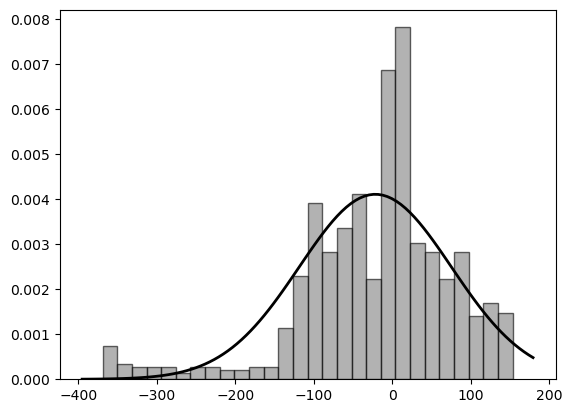

In [14]:
dir_name = 'asymmetry_tests/8500_template'

uninj_save_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/{dir_name}/normalized_uninjected/'
inj_save_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/{dir_name}/normalized_injected/'
temp_save_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/{dir_name}/normalized_template/'

plot_dist(save_dirs=(uninj_save_dir, inj_save_dir, temp_save_dir))

# Checking if start/stop normalization works!

Time: 6.7956719398498535


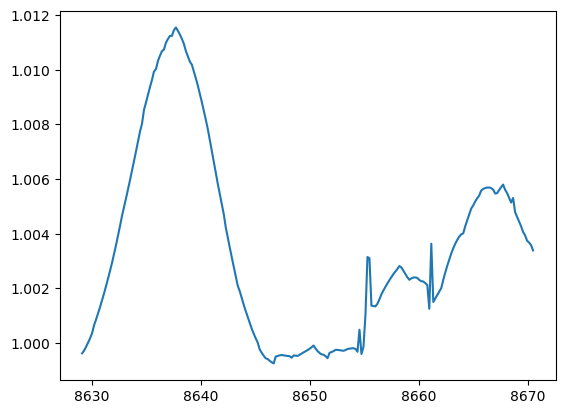

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
os.chdir('/home/bhanselman/scripts')
from normalization_methods import *

bank = 0
data_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/preprocessed/{bank}'
name = os.listdir(data_dir)[1]
spectrum = np.load(os.path.join(data_dir, name))
freq = 8680

start = time.time()
norm_spectrum = normalize_dynamic(spectrum, start=8600, stop=8700, interior=1.4, exterior=7)
end = time.time()
print(f'Time: {end - start}')
plt.plot(*norm_spectrum)

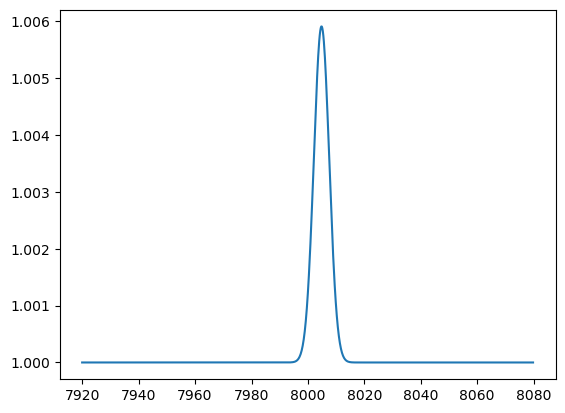

In [ ]:
injected_dir = f'/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/data/template/ann/'
files = os.listdir(injected_dir)
spec = np.load(os.path.join(injected_dir, files[3500]))
plt.plot(*spec)

# Do doppler asymmetries suck

[[0.99948192 0.99943184 0.99938462 ... 0.99889955 0.99895357 0.9990095 ]
 [1.00061032 1.00055699 1.00050254 ... 0.99904004 0.99911816 0.99919749]
 [0.99925656 0.99920536 0.99915812 ... 0.99868812 0.99875341 0.99882146]
 ...
 [0.99942401 0.99938371 0.99934637 ... 0.99906887 0.99912334 0.99917849]
 [0.99933432 0.99927624 0.99922239 ... 0.99866216 0.99875399 0.9988487 ]
 [1.00066753 1.00060954 1.00055006 ... 0.99902888 0.99911401 0.99920029]]
[[0.99946149 0.99940691 0.99935526 ... 0.99861597 0.99867597 0.99873869]
 [1.00067426 1.00061671 1.00055756 ... 0.99907134 0.99915593 0.99924152]
 [0.99958473 0.99954973 0.99951683 ... 0.99931396 0.9993509  0.99938846]
 ...
 [0.99929898 0.99925509 0.99921422 ... 0.99878675 0.9988317  0.99887907]
 [0.99958968 0.99955536 0.99952279 ... 0.99930849 0.9993341  0.99936054]
 [0.99960642 0.99957395 0.99954337 ... 0.99918203 0.99921116 0.99924143]]
[[0.99918476 0.99913347 0.99908704 ... 0.9987077  0.99880473 0.9989045 ]
 [1.0006641  1.00060703 1.00054846 ... 

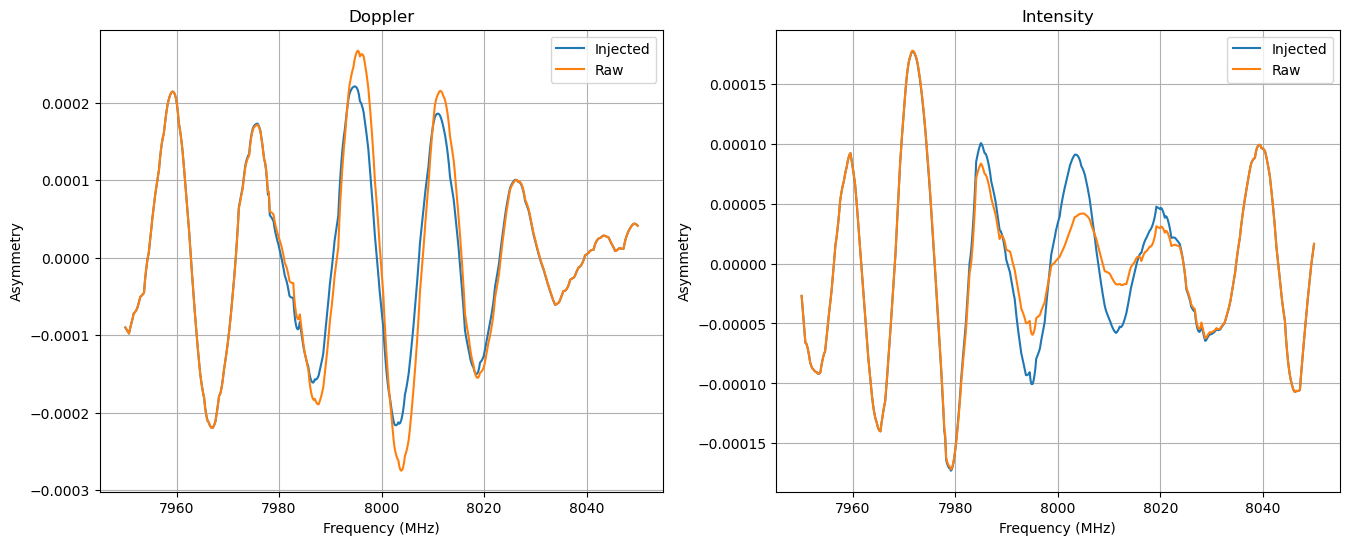

In [6]:
data_dir = '/home/dataadmin/GBTData/SharedDataDirectory/xband_072625/analyses/8000_8500_mhz_weighted_optimized/decay/8000/optimization'
uninj_dir = os.path.join(data_dir, 'normalized_uninjected')
inj_dir = os.path.join(data_dir, 'normalized_injected')

doppler_inj_xs, doppler_inj_ys = build_asymmetry(inj_dir, info, 'theta', 65, 65)
doppler_uninj_xs, doppler_uninj_ys = build_asymmetry(uninj_dir, info, 'theta', 65, 65)
intensity_inj_xs, intensity_inj_ys = build_asymmetry(inj_dir, info, 'phi', 70, 115)
intensity_uninj_xs, intensity_uninj_ys = build_asymmetry(uninj_dir, info, 'phi', 70, 115)

fig, axs = plt.subplots(1, 2, figsize=(16,6))
axs[0].plot(doppler_inj_xs, doppler_inj_ys, label='Injected')
axs[0].plot(doppler_uninj_xs, doppler_uninj_ys, label='Raw')
axs[0].set_title('Doppler')
axs[1].plot(intensity_inj_xs, intensity_inj_ys, label='Injected')
axs[1].plot(intensity_uninj_xs, intensity_uninj_ys, label='Raw')
axs[1].set_title('Intensity')
for ax in axs:
    ax.grid()
    ax.set_xlabel('Frequency (MHz)')
    ax.set_ylabel('Asymmetry')
    ax.legend()